<a href="https://colab.research.google.com/github/JoshuaEmor/Animation-Nation/blob/master/neural_network_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Neural Network Classification
## BCO7007 Assessment 3 — Retail Transaction Dataset

**Target Variable:** `CustomerGender` (female / male / other)  
**Features:** `CustomerAge`, `Quantity`, `UnitPrice`, `Country` (encoded)  
**Task:** Multi-class classification using a Multilayer Perceptron (MLP) Neural Network


## 1. Import Libraries

In [1]:
from google.colab import files
files.upload('bco7007_assessment3_v2 - small.xlsx')  # select the .xlsx file

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
print('All libraries imported successfully.')

Saving bco7007_assessment3_v2 - small.xlsx to bco7007_assessment3_v2 - small.xlsx/bco7007_assessment3_v2 - small.xlsx
All libraries imported successfully.


## 2. Load Dataset

In [5]:
df = pd.read_excel('bco7007_assessment3_v2 - small.xlsx/bco7007_assessment3_v2 - small.xlsx')
df = df.sample(n=5000, random_state=42)  # use 5000 rows instead of all
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (5000, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CustomerAge,CustomerGender
211392,555368,22727,ALARM CLOCK BAKELIKE RED,4,2011-06-02 14:30:00,3.75,13437.0,United Kingdom,39,female
136792,547986,21928,JUMBO BAG SCANDINAVIAN BLUE PAISLEY,10,2011-03-29 08:46:00,1.95,18177.0,United Kingdom,33,male
56564,541104,21658,GLASS BEURRE DISH,3,2011-01-13 14:29:00,8.29,NaN,United Kingdom,58,female
259993,559794,22997,TRAVEL CARD WALLET UNION JACK,24,2011-07-12 13:16:00,0.42,16700.0,United Kingdom,41,male
230767,557217,22427,ENAMEL FLOWER JUG CREAM,3,2011-06-17 12:30:00,5.95,17426.0,United Kingdom,60,male


## 3. Exploratory Data Analysis (EDA)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 211392 to 73562
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   InvoiceNo       5000 non-null   object        
 1   StockCode       5000 non-null   object        
 2   Description     4982 non-null   object        
 3   Quantity        5000 non-null   int64         
 4   InvoiceDate     5000 non-null   datetime64[ns]
 5   UnitPrice       5000 non-null   float64       
 6   CustomerID      3629 non-null   float64       
 7   Country         5000 non-null   object        
 8   CustomerAge     5000 non-null   int64         
 9   CustomerGender  5000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 429.7+ KB


In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,CustomerAge
count,5000.000000,5000,5000.000000,3629.000000,5000.00000
mean,9.923800,2011-04-08 09:18:07.896000,4.250880,15293.693579,43.44420
min,-100.000000,2010-12-01 08:34:00,0.000000,12350.000000,18.00000
25%,1.000000,2011-01-28 06:08:45,1.250000,13862.000000,30.00000
50%,3.000000,2011-04-08 15:42:00,2.100000,15182.000000,44.00000
75%,10.000000,2011-06-16 12:55:00,4.130000,16810.000000,56.00000
max,1440.000000,2011-08-18 15:17:00,1867.860000,18283.000000,69.00000
std,35.662181,NaN,36.264333,1723.806023,15.10828


In [8]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
InvoiceNo            0
StockCode            0
Description         18
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID        1371
Country              0
CustomerAge          0
CustomerGender       0
dtype: int64


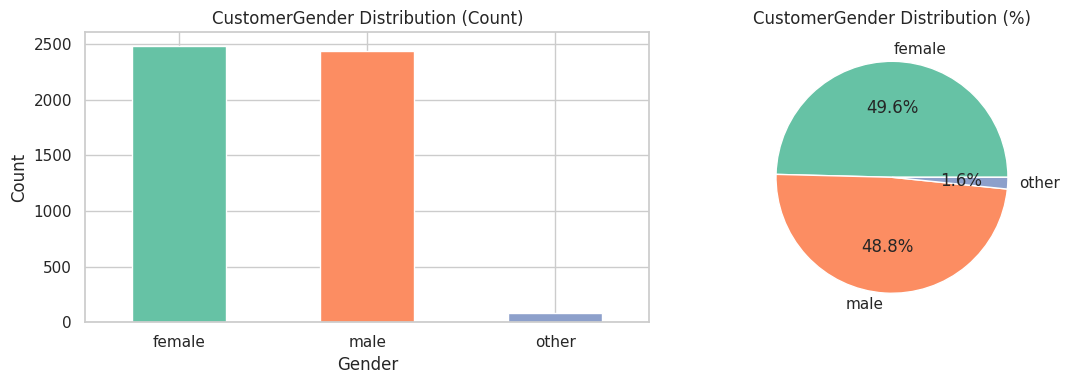

In [9]:
# Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['CustomerGender'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('CustomerGender Distribution (Count)')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['CustomerGender'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                          colors=sns.color_palette('Set2'))
axes[1].set_title('CustomerGender Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

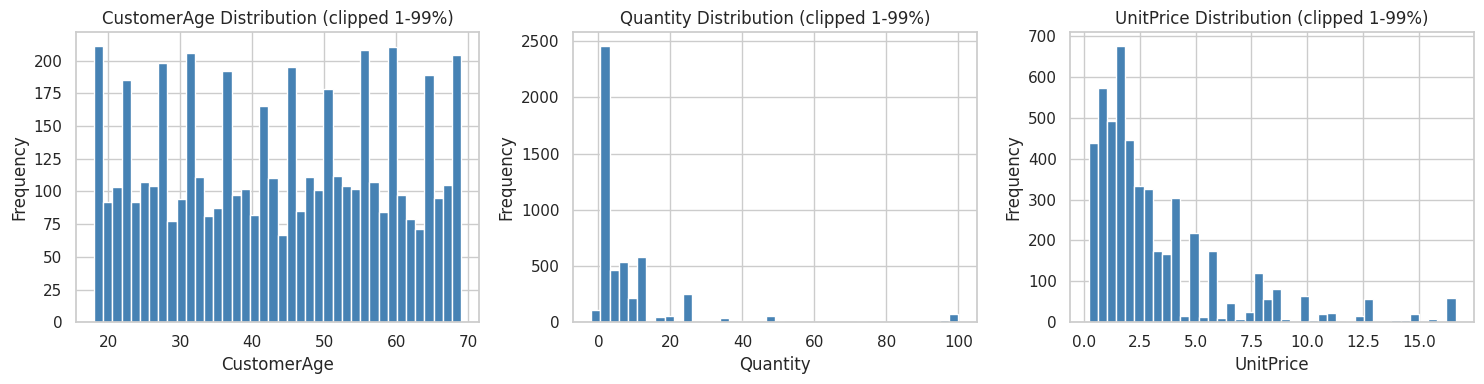

In [10]:
# Numerical feature distributions
num_cols = ['CustomerAge', 'Quantity', 'UnitPrice']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99)).hist(
        ax=ax, bins=40, color='steelblue', edgecolor='white'
    )
    ax.set_title(f'{col} Distribution (clipped 1-99%)')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

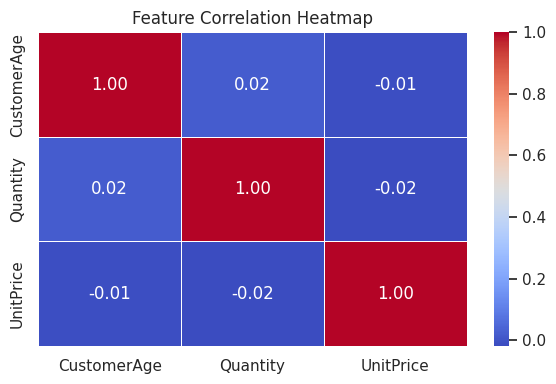

In [11]:
# Correlation heatmap of numeric features
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [12]:
# Select relevant features and target
data = df[['CustomerAge', 'Quantity', 'UnitPrice', 'Country', 'CustomerGender']].copy()

# Drop rows with missing values
data.dropna(inplace=True)

# Remove returns and data errors (negative quantity or price)
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]

# Clip extreme outliers at 99th percentile
for col in ['Quantity', 'UnitPrice']:
    upper = data[col].quantile(0.99)
    data[col] = data[col].clip(upper=upper)

print(f'Cleaned dataset shape: {data.shape}')
data.head()

Cleaned dataset shape: (4878, 5)


,CustomerAge,Quantity,UnitPrice,Country,CustomerGender
211392,39,4,3.75,United Kingdom,female
136792,33,10,1.95,United Kingdom,male
56564,58,3,8.29,United Kingdom,female
259993,41,24,0.42,United Kingdom,male
230767,60,3,5.95,United Kingdom,male


In [13]:
# Encode Country — keep top 10, group rest as 'Other'
top_countries = data['Country'].value_counts().nlargest(10).index
data['Country'] = data['Country'].apply(lambda x: x if x in top_countries else 'Other')

le_country = LabelEncoder()
data['Country_enc'] = le_country.fit_transform(data['Country'])

# Encode target variable
le_gender = LabelEncoder()
data['Gender_enc'] = le_gender.fit_transform(data['CustomerGender'])

print('Gender classes :', le_gender.classes_)
print('Country classes:', le_country.classes_)

Gender classes : ['female' 'male' 'other']
Country classes: ['Belgium' 'Cyprus' 'EIRE' 'France' 'Germany' 'Netherlands' 'Other'
 'Portugal' 'Spain' 'Switzerland' 'United Kingdom']


## 5. Feature Selection & Train-Test Split

In [14]:
FEATURES = ['CustomerAge', 'Quantity', 'UnitPrice', 'Country_enc']
TARGET   = 'Gender_enc'

X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')

Training set : 3,902 samples
Test set     : 976 samples


In [15]:
# Feature scaling — essential for neural networks
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Features scaled with StandardScaler.')

Features scaled with StandardScaler.


## 6. Neural Network Architecture

We use scikit-learn's `MLPClassifier` (Multilayer Perceptron) with the following architecture:

```
Input Layer   →  4 neurons  (one per feature)
Hidden Layer 1 → 64 neurons  (ReLU activation)
Hidden Layer 2 → 32 neurons  (ReLU activation)
Output Layer  →  3 neurons  (Softmax — one per gender class)
```

- **Optimizer:** Adam (adaptive learning rate)
- **Regularisation:** L2 (alpha)
- **Early Stopping:** enabled to prevent overfitting


## 7. Baseline Neural Network Model

In [16]:
mlp_base = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # Two hidden layers
    activation='relu',
    solver='adam',
    alpha=0.0001,                  # L2 regularisation
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=False
)

mlp_base.fit(X_train_sc, y_train)

y_pred_base = mlp_base.predict(X_test_sc)
print(f'Baseline MLP Accuracy: {accuracy_score(y_test, y_pred_base):.4f}')
print(f'Epochs trained       : {mlp_base.n_iter_}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_base, target_names=le_gender.classes_))

Baseline MLP Accuracy: 0.4867
Epochs trained       : 12

Classification Report:
              precision    recall  f1-score   support

      female       0.48      0.05      0.08       485
        male       0.49      0.95      0.64       476
       other       0.00      0.00      0.00        15

    accuracy                           0.49       976
   macro avg       0.32      0.33      0.24       976
weighted avg       0.48      0.49      0.36       976



## 8. Training Loss Curve

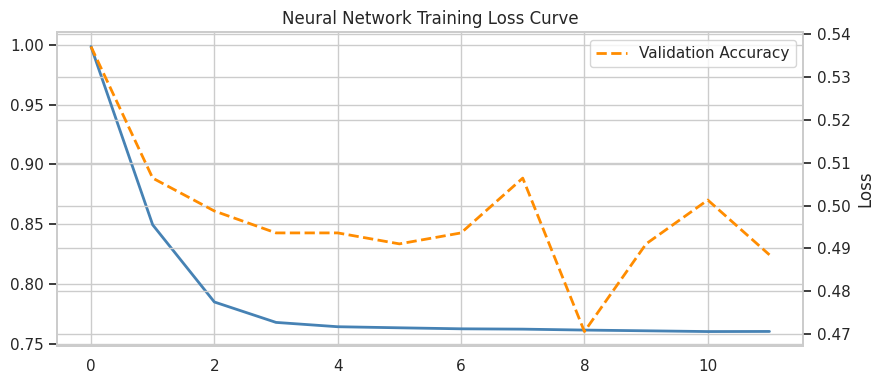

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(mlp_base.loss_curve_, label='Training Loss', linewidth=2, color='steelblue')
if hasattr(mlp_base, 'validation_scores_') and mlp_base.validation_scores_ is not None:
    # Plot validation score on secondary axis
    ax2 = plt.gca().twinx()
    ax2.plot(mlp_base.validation_scores_, label='Validation Accuracy',
             linewidth=2, color='darkorange', linestyle='--')
    ax2.set_ylabel('Validation Accuracy')
    ax2.legend(loc='lower right')

plt.title('Neural Network Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 9. Experimenting with Different Architectures

In [18]:
architectures = {
    'Shallow (32)':     (32,),
    'Medium (64-32)':   (64, 32),
    'Deep (128-64-32)': (128, 64, 32),
}

results = []
for name, layers in architectures.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        alpha=0.0001,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_sc, y_train)
    train_acc = accuracy_score(y_train, mlp.predict(X_train_sc))
    test_acc  = accuracy_score(y_test,  mlp.predict(X_test_sc))
    results.append({'Architecture': name, 'Train Accuracy': train_acc,
                    'Test Accuracy': test_acc, 'Epochs': mlp.n_iter_})
    print(f'{name:30s} | Train: {train_acc:.4f} | Test: {test_acc:.4f} | Epochs: {mlp.n_iter_}')

results_df = pd.DataFrame(results)

Shallow (32)                   | Train: 0.5187 | Test: 0.5379 | Epochs: 45
Medium (64-32)                 | Train: 0.4928 | Test: 0.4867 | Epochs: 12
Deep (128-64-32)               | Train: 0.5290 | Test: 0.5246 | Epochs: 16


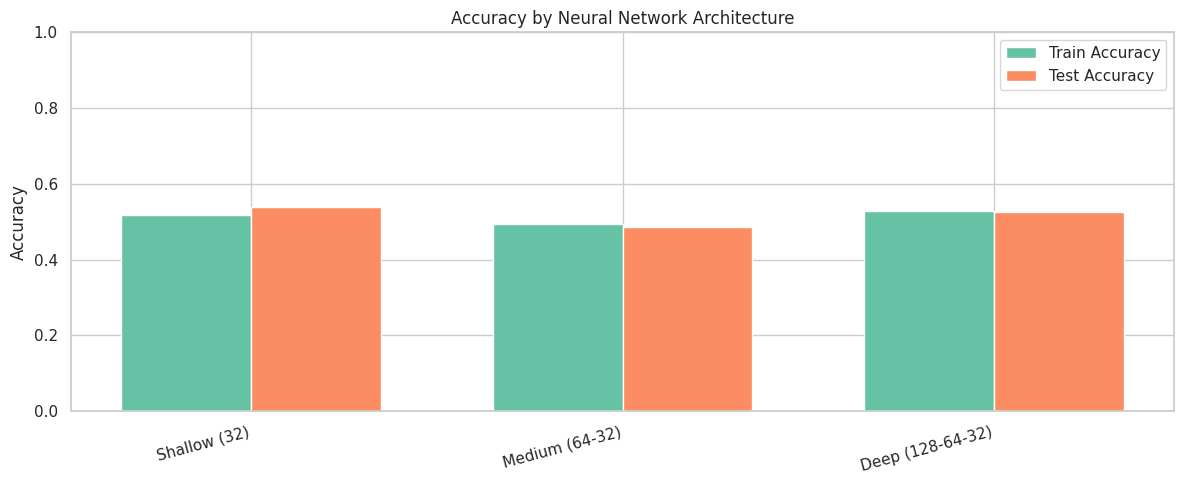

In [19]:
# Visualise architecture comparison
x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy',
       color=sns.color_palette('Set2')[0])
ax.bar(x + width/2, results_df['Test Accuracy'],  width, label='Test Accuracy',
       color=sns.color_palette('Set2')[1])
ax.set_xticks(x)
ax.set_xticklabels(results_df['Architecture'], rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Neural Network Architecture')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Effect of Activation Functions

Activation: relu       | Test Accuracy: 0.4867
Activation: tanh       | Test Accuracy: 0.5369


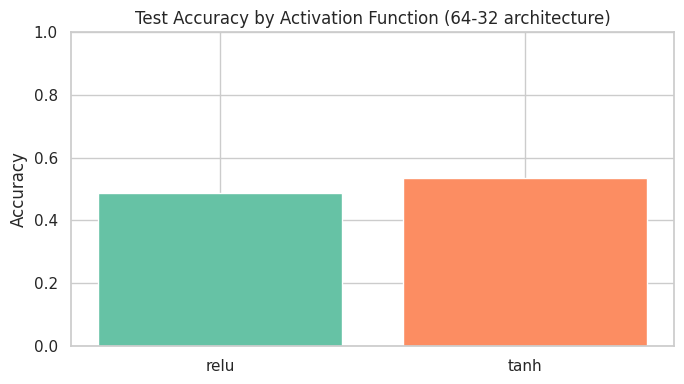

In [21]:
activations = ['relu', 'tanh']
act_results = []

for act in activations:
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=act,
        solver='adam',
        max_iter=100,
        early_stopping=True,
        random_state=42
    )
    mlp.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, mlp.predict(X_test_sc))
    act_results.append({'Activation': act, 'Test Accuracy': acc})
    print(f'Activation: {act:10s} | Test Accuracy: {acc:.4f}')

act_df = pd.DataFrame(act_results)

plt.figure(figsize=(7, 4))
plt.bar(act_df['Activation'], act_df['Test Accuracy'],
        color=sns.color_palette('Set2')[:3], edgecolor='white')
plt.title('Test Accuracy by Activation Function (64-32 architecture)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 11. Final Best Model

In [24]:
# Select the best architecture from Section 9 results
best_arch_row = results_df.loc[results_df['Test Accuracy'].idxmax()]
best_arch_name = best_arch_row['Architecture']
best_layers = architectures[best_arch_name]

# Select best activation from Section 10
best_act = act_df.loc[act_df['Test Accuracy'].idxmax(), 'Activation']

print(f'Best Architecture : {best_arch_name} → layers={best_layers}')
print(f'Best Activation   : {best_act}')

best_mlp = MLPClassifier(
    hidden_layer_sizes=best_layers,
    activation=best_act,
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42
)

best_mlp.fit(X_train_sc, y_train)
y_pred_best = best_mlp.predict(X_test_sc)

print(f'\nFinal Model Test Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Epochs trained            : {best_mlp.n_iter_}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=le_gender.classes_))

Best Architecture : Shallow (32) → layers=(32,)
Best Activation   : tanh

Final Model Test Accuracy : 0.5287
Epochs trained            : 51

Classification Report:
              precision    recall  f1-score   support

      female       0.53      0.62      0.57       485
        male       0.53      0.45      0.49       476
       other       0.00      0.00      0.00        15

    accuracy                           0.53       976
   macro avg       0.35      0.36      0.35       976
weighted avg       0.52      0.53      0.52       976



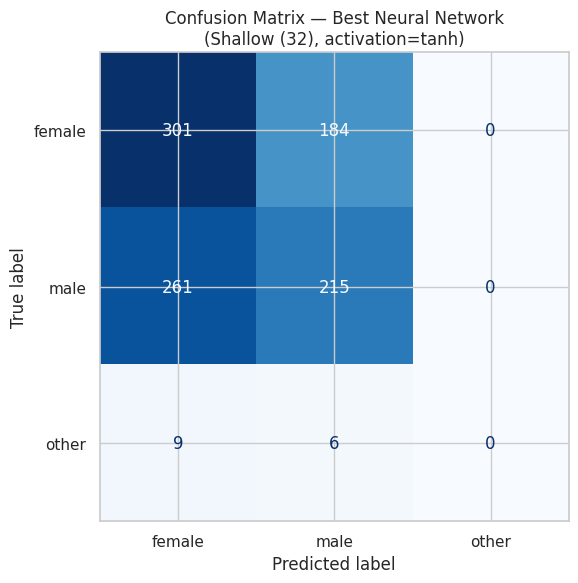

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_gender.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — Best Neural Network\n({best_arch_name}, activation={best_act})')
plt.tight_layout()
plt.show()

## 12. Cross-Validation (5-Fold)

5-Fold Cross-Validation Accuracy:
  Fold 1: 0.4942
  Fold 2: 0.4968
  Fold 3: 0.4974
  Fold 4: 0.4923
  Fold 5: 0.4936

Mean CV Accuracy : 0.4949
Std CV Accuracy  : 0.0019


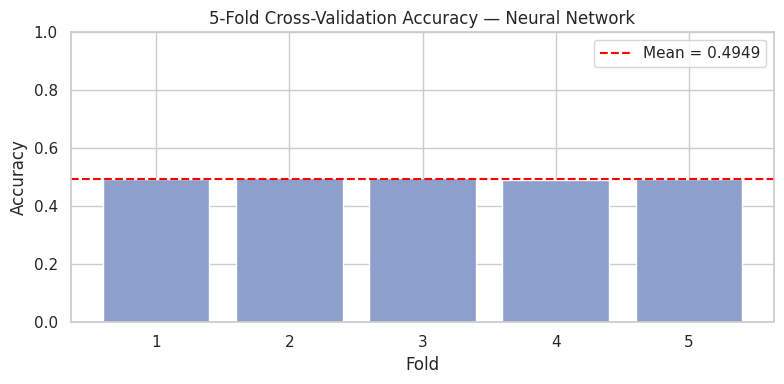

In [25]:
cv_mlp = MLPClassifier(
    hidden_layer_sizes=best_layers,
    activation=best_act,
    solver='adam',
    max_iter=100,
    early_stopping=True,
    random_state=42
)

cv_scores = cross_val_score(cv_mlp, X_train_sc, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print('5-Fold Cross-Validation Accuracy:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\nMean CV Accuracy : {cv_scores.mean():.4f}')
print(f'Std CV Accuracy  : {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color=sns.color_palette('Set2')[2], edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross-Validation Accuracy — Neural Network')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 13. Prediction Probabilities

In [26]:
# Show predicted probabilities for first 10 test samples
proba = best_mlp.predict_proba(X_test_sc[:10])
proba_df = pd.DataFrame(proba, columns=le_gender.classes_)
proba_df['Predicted'] = le_gender.classes_[np.argmax(proba, axis=1)]
proba_df['Actual']    = le_gender.inverse_transform(y_test.values[:10])
proba_df['Correct']   = proba_df['Predicted'] == proba_df['Actual']
proba_df.round(3)

,female,male,other,Predicted,Actual,Correct
0,0.485,0.499,0.015,male,female,False
1,0.511,0.469,0.020,female,male,False
2,0.475,0.508,0.018,male,other,False
3,0.463,0.516,0.020,male,male,True
4,0.471,0.510,0.019,male,male,True
5,0.477,0.506,0.017,male,female,False
6,0.480,0.503,0.017,male,male,True
7,0.503,0.482,0.015,female,male,False
8,0.542,0.441,0.017,female,male,False
9,0.475,0.507,0.018,male,male,True


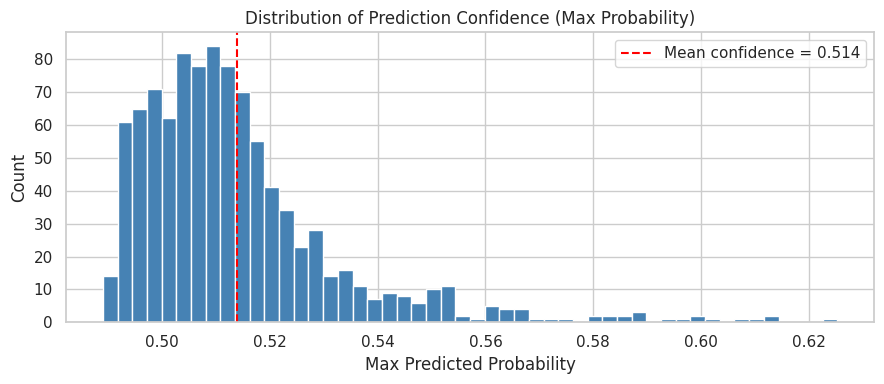

In [27]:
# Distribution of prediction confidence (max probability per sample)
all_proba = best_mlp.predict_proba(X_test_sc)
confidence = all_proba.max(axis=1)

plt.figure(figsize=(9, 4))
plt.hist(confidence, bins=50, color='steelblue', edgecolor='white')
plt.axvline(confidence.mean(), color='red', linestyle='--',
            label=f'Mean confidence = {confidence.mean():.3f}')
plt.title('Distribution of Prediction Confidence (Max Probability)')
plt.xlabel('Max Predicted Probability')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## 14. Feature Importance (Permutation-Based)

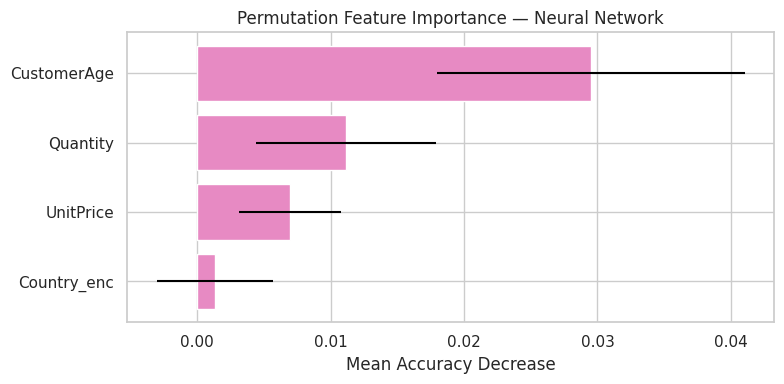

    Feature  Importance      Std
CustomerAge    0.029508 0.011517
   Quantity    0.011168 0.006726
  UnitPrice    0.006967 0.003828
Country_enc    0.001332 0.004372


In [28]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_mlp, X_test_sc, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': perm.importances_mean,
    'Std'       : perm.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(perm_df['Feature'], perm_df['Importance'],
         xerr=perm_df['Std'], color=sns.color_palette('Set2')[3], edgecolor='white')
plt.title('Permutation Feature Importance — Neural Network')
plt.xlabel('Mean Accuracy Decrease')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(perm_df.to_string(index=False))

## 15. Model Summary

| Metric | Value |
|--------|-------|
| **Model** | Multilayer Perceptron (MLP) Neural Network |
| **Target** | CustomerGender (female / male / other) |
| **Features** | CustomerAge, Quantity, UnitPrice, Country_enc |
| **Architecture** | Selected from Section 9 experiment |
| **Activation** | Selected from Section 10 experiment |
| **Optimizer** | Adam |
| **Regularisation** | L2 (alpha=0.0001) |
| **Early Stopping** | Enabled (patience=15) |
| **Test Accuracy** | See Section 11 |
| **CV Mean Accuracy** | See Section 12 |

### Key Observations
- Feature scaling with `StandardScaler` is critical — neural networks are sensitive to feature magnitude.
- Early stopping prevents overfitting by monitoring validation accuracy.
- The loss curve (Section 8) shows how the network converges over epochs.
- Permutation importance reveals which features contribute most to prediction.
- Prediction probabilities (Section 13) give insight into model confidence per class.
